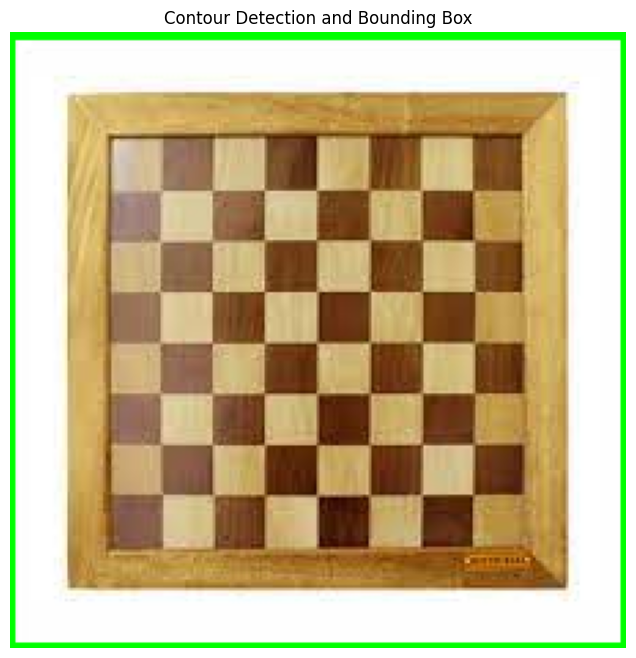

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Set the filename ---
IMAGE_FILE = 'xadrez.jpg'

## 1. Load and Preprocess the Image
# The script assumes 'mia.jpg' is in the same directory as the script.
img = cv2.imread(IMAGE_FILE)

if img is None:
    print(f"Error: Could not load image file '{IMAGE_FILE}'")
    exit()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to remove noise and help edge detection
# Kernel size (5, 5) and 0 standard deviation
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

## 2. Apply Canny Edge Detection
# Canny is a robust edge detector. You may need to tune the thresholds.
canny_output = cv2.Canny(blurred, 30, 90)

## 3. Find and Filter Contours
# cv2.RETR_EXTERNAL retrieves only the extreme outer contours.
# cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments.
contours, hierarchy = cv2.findContours(canny_output, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the largest contour, which is most likely the cat
if contours:
    # Sort the contours by area in descending order
    largest_contour = max(contours, key=cv2.contourArea)

    # Filter out very small areas that are likely noise
    MIN_AREA_THRESHOLD = 500  # Adjust this value based on image resolution
    
    if cv2.contourArea(largest_contour) > MIN_AREA_THRESHOLD:
        
        ## 4. Draw the Bounding Rectangle
        # Get the coordinates (x, y), width (w), and height (h) of the bounding box
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Draw the rectangle on the original image (Green color: BGR 0, 255, 0)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Optional: Draw the full contour to see what was detected (Blue color)
        # cv2.drawContours(img, [largest_contour], 0, (255, 0, 0), 2)
        
    else:
        print("No significant contour found above the area threshold.")
else:
    print("No contours were found.")

## 5. Display the Result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Contour Detection and Bounding Box')
plt.axis('off')
plt.show()

# --- End of Script ---